In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Loading data
# Define paths
base_path = os.path.expanduser('~/data/data/')
train_bp_path = os.path.join(base_path, 'train/BP/')
train_sz_path = os.path.join(base_path, 'train/SZ/')
test_path     = os.path.join(base_path, 'test/')

def load_patients(folder_path, label, label_name):
    """Load all FNC files from a folder"""
    features = []
    patient_ids = []
    
    patients = sorted(os.listdir(folder_path))
    
    for patient in patients:
        fnc_file = os.path.join(folder_path, patient, 'fnc.npy')
        if os.path.exists(fnc_file):
            fnc = np.load(fnc_file).flatten()  # Ensure shape (5460,)
            features.append(fnc)
            patient_ids.append(patient)
    
    features = np.array(features)
    labels = np.full(len(features), label)
    
    print(f"✓ Loaded {len(features)} {label_name} patients | Shape: {features.shape}")
    return features, labels, patient_ids

# Load BP patients (label = 0)
X_bp, y_bp, ids_bp = load_patients(train_bp_path, 0, 'BP')

# Load SZ patients (label = 1)
X_sz, y_sz, ids_sz = load_patients(train_sz_path, 1, 'SZ')

# Combine
X_train = np.vstack([X_bp, X_sz])
y_train = np.concatenate([y_bp, y_sz])
patient_ids = ids_bp + ids_sz

print(f"\n{'='*50}")
print(f"FINAL DATASET:")
print(f"Total patients : {X_train.shape[0]}")
print(f"Total features : {X_train.shape[1]}")
print(f"BP patients    : {np.sum(y_train == 0)}")
print(f"SZ patients    : {np.sum(y_train == 1)}")
print(f"{'='*50}")

✓ Loaded 183 BP patients | Shape: (183, 5460)
✓ Loaded 288 SZ patients | Shape: (288, 5460)

FINAL DATASET:
Total patients : 471
Total features : 5460
BP patients    : 183
SZ patients    : 288


In [3]:
# Data quality check
print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

# Check for issues
n_nan = np.isnan(X_train).sum()
n_inf = np.isinf(X_train).sum()
n_outside = np.sum((X_train < -1) | (X_train > 1))

print(f"\n1. NaN values      : {n_nan}")
print(f"2. Inf values      : {n_inf}")
print(f"3. Values outside [-1,1]: {n_outside}")
print(f"4. Min value       : {X_train.min():.4f}")
print(f"5. Max value       : {X_train.max():.4f}")
print(f"6. Overall mean    : {X_train.mean():.4f}")
print(f"7. Overall std     : {X_train.std():.4f}")

# Check each patient's value range
patient_mins = X_train.min(axis=1)
patient_maxs = X_train.max(axis=1)
patient_means = X_train.mean(axis=1)

print(f"\nPer-patient statistics:")
print(f"  Mean of patient means : {patient_means.mean():.4f}")
print(f"  Std of patient means  : {patient_means.std():.4f}")

if n_nan == 0 and n_inf == 0:
    print("\n✓ Data is clean! No NaN or Inf values")
else:
    print("\n⚠ Data has issues - needs cleaning!")

DATA QUALITY CHECK

1. NaN values      : 0
2. Inf values      : 0
3. Values outside [-1,1]: 0
4. Min value       : -0.9889
5. Max value       : 0.9993
6. Overall mean    : 0.0228
7. Overall std     : 0.2625

Per-patient statistics:
  Mean of patient means : 0.0228
  Std of patient means  : 0.0117

✓ Data is clean! No NaN or Inf values


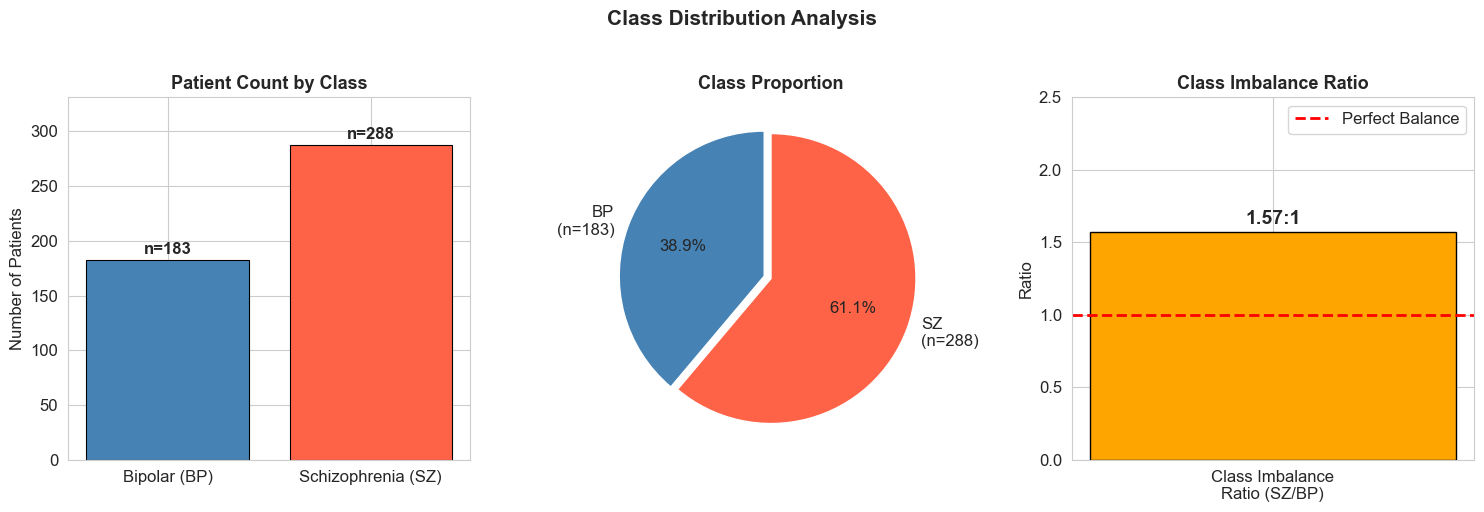

Imbalance ratio: 1.57:1 (SZ:BP)
→ Moderate imbalance - use balanced class weights in SVM


In [4]:
# EDA - Class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_bp = np.sum(y_train == 0)
n_sz = np.sum(y_train == 1)
total = len(y_train)

# Bar plot
bars = axes[0].bar(['Bipolar (BP)', 'Schizophrenia (SZ)'],
                   [n_bp, n_sz],
                   color=['steelblue', 'tomato'],
                   edgecolor='black', linewidth=0.8)

axes[0].set_title('Patient Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(n_bp, n_sz) * 1.15)

# Add count labels on bars
for bar, count in zip(bars, [n_bp, n_sz]):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 5,
                 f'n={count}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie([n_bp, n_sz],
            labels=[f'BP\n(n={n_bp})', f'SZ\n(n={n_sz})'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90,
            explode=(0.05, 0))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

# Imbalance info
ratio = n_sz / n_bp
axes[2].bar(['Class Imbalance\nRatio (SZ/BP)'], [ratio],
            color='orange', edgecolor='black')
axes[2].axhline(1.0, color='red', linestyle='--', 
                linewidth=2, label='Perfect Balance')
axes[2].set_title('Class Imbalance Ratio', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Ratio')
axes[2].set_ylim(0, 2.5)
axes[2].text(0, ratio + 0.05, f'{ratio:.2f}:1', 
             ha='center', fontweight='bold', fontsize=14)
axes[2].legend()

plt.suptitle('Class Distribution Analysis', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {ratio:.2f}:1 (SZ:BP)")
print(f"→ Moderate imbalance - use balanced class weights in SVM")

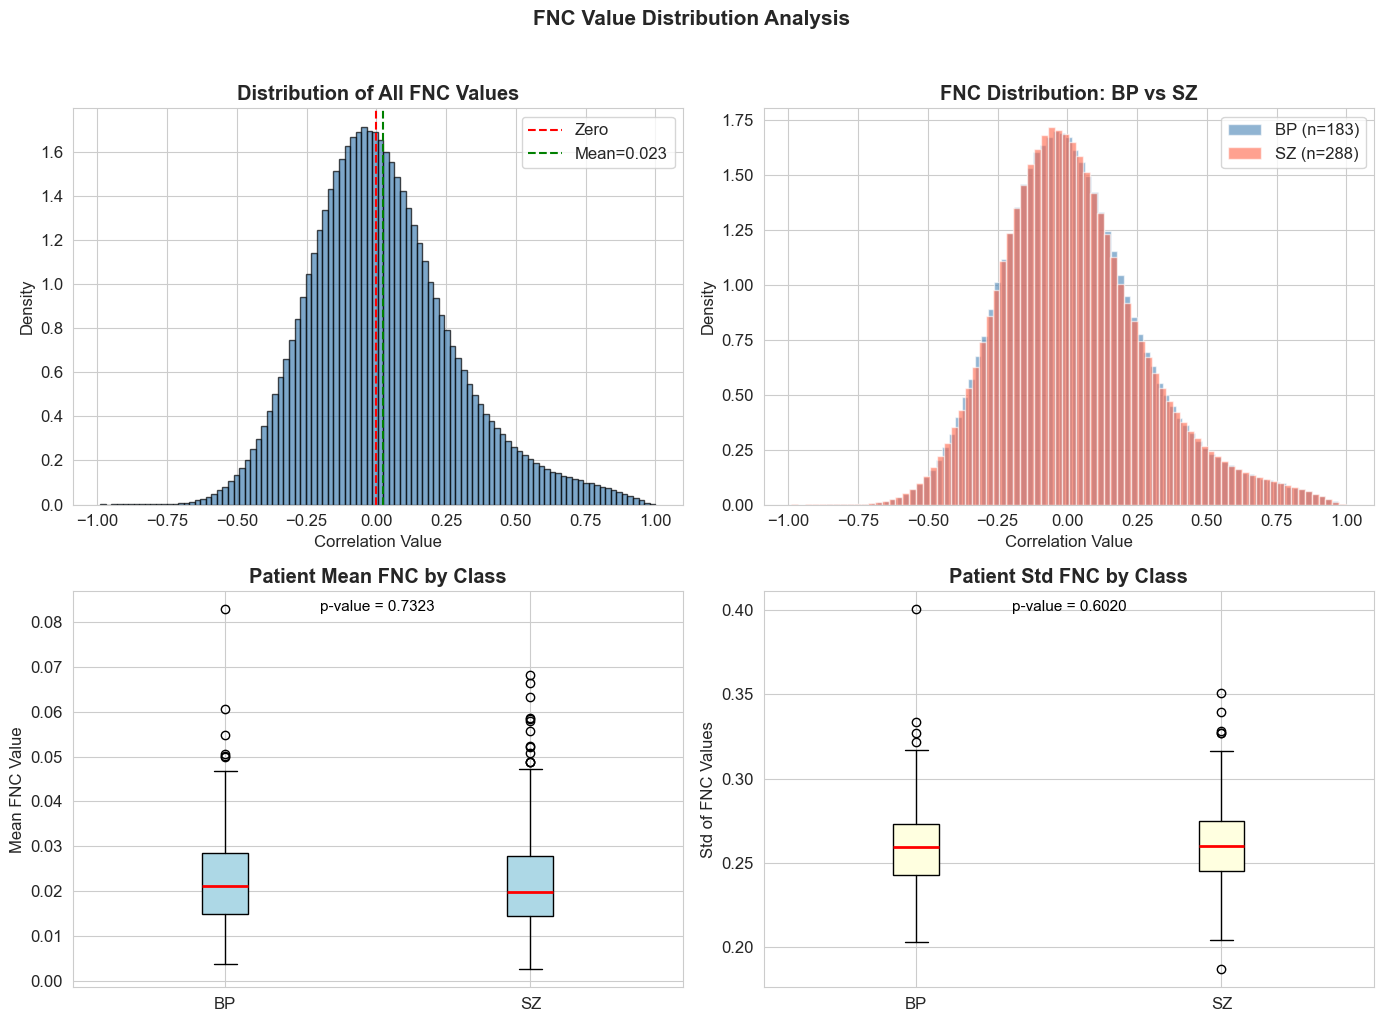

In [5]:
# EDA FNC value distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall distribution
axes[0, 0].hist(X_train.flatten(), bins=100, 
                color='steelblue', edgecolor='black',
                alpha=0.7, density=True)
axes[0, 0].set_title('Distribution of All FNC Values', fontweight='bold')
axes[0, 0].set_xlabel('Correlation Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].axvline(0, color='red', linestyle='--', 
                   linewidth=1.5, label='Zero')
axes[0, 0].axvline(X_train.mean(), color='green', linestyle='--',
                   linewidth=1.5, label=f'Mean={X_train.mean():.3f}')
axes[0, 0].legend()

# 2. BP vs SZ distributions
axes[0, 1].hist(X_train[y_train==0].flatten(), bins=80,
                alpha=0.6, color='steelblue', 
                label=f'BP (n={n_bp})', density=True)
axes[0, 1].hist(X_train[y_train==1].flatten(), bins=80,
                alpha=0.6, color='tomato',
                label=f'SZ (n={n_sz})', density=True)
axes[0, 1].set_title('FNC Distribution: BP vs SZ', fontweight='bold')
axes[0, 1].set_xlabel('Correlation Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# 3. Patient mean FNC values
bp_means = X_train[y_train==0].mean(axis=1)
sz_means = X_train[y_train==1].mean(axis=1)

axes[1, 0].boxplot([bp_means, sz_means],
                   labels=['BP', 'SZ'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Patient Mean FNC by Class', fontweight='bold')
axes[1, 0].set_ylabel('Mean FNC Value')

# T-test on means
t_stat, p_val = stats.ttest_ind(bp_means, sz_means)
axes[1, 0].text(0.5, 0.95, f'p-value = {p_val:.4f}',
                transform=axes[1, 0].transAxes,
                ha='center', fontsize=11,
                color='red' if p_val < 0.05 else 'black')

# 4. Patient std FNC values
bp_stds = X_train[y_train==0].std(axis=1)
sz_stds = X_train[y_train==1].std(axis=1)

axes[1, 1].boxplot([bp_stds, sz_stds],
                   labels=['BP', 'SZ'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightyellow'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Patient Std FNC by Class', fontweight='bold')
axes[1, 1].set_ylabel('Std of FNC Values')

t_stat2, p_val2 = stats.ttest_ind(bp_stds, sz_stds)
axes[1, 1].text(0.5, 0.95, f'p-value = {p_val2:.4f}',
                transform=axes[1, 1].transAxes,
                ha='center', fontsize=11,
                color='red' if p_val2 < 0.05 else 'black')

plt.suptitle('FNC Value Distribution Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_2_fnc_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE-LEVEL STATISTICS
Features with var > 0.01  : 5437
Features with var > 0.001 : 5460
Features with var < 0.001 : 0 (low info)

Max variance feature index: 4925
Max variance value        : 0.068397
Max group difference      : 0.0761


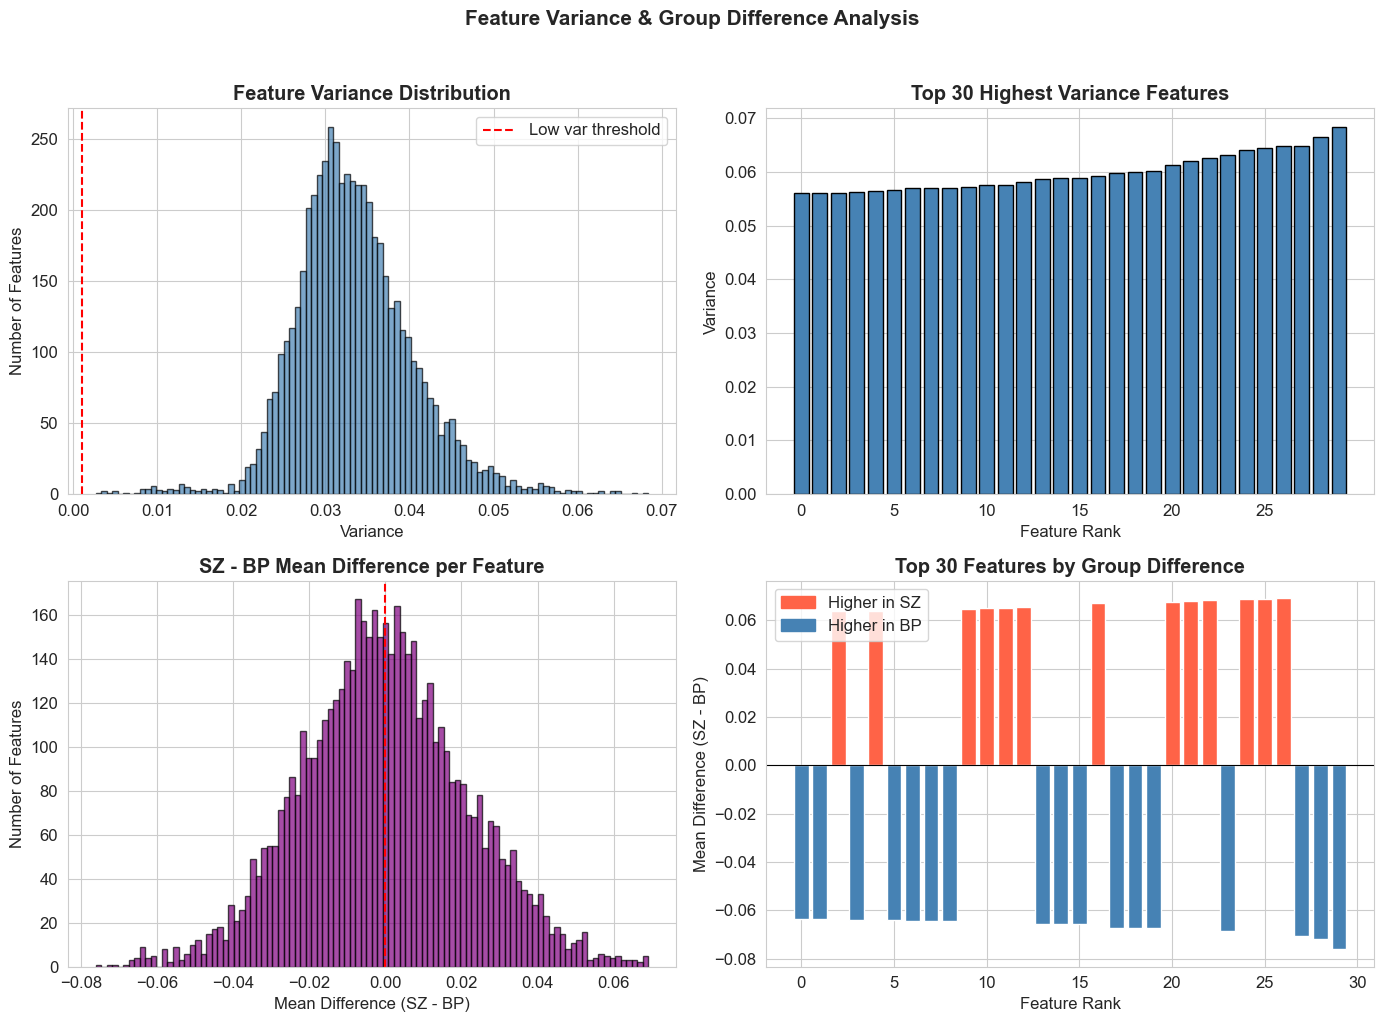

In [6]:
# EDA Feature variance analysis
# Calculate feature-level statistics
feature_means = X_train.mean(axis=0)     # Mean per feature
feature_vars  = X_train.var(axis=0)      # Variance per feature
feature_stds  = X_train.std(axis=0)      # Std per feature

# Group-specific means
bp_feature_means = X_train[y_train==0].mean(axis=0)
sz_feature_means = X_train[y_train==1].mean(axis=0)
group_difference = sz_feature_means - bp_feature_means

print("="*50)
print("FEATURE-LEVEL STATISTICS")
print("="*50)
print(f"Features with var > 0.01  : {np.sum(feature_vars > 0.01)}")
print(f"Features with var > 0.001 : {np.sum(feature_vars > 0.001)}")
print(f"Features with var < 0.001 : {np.sum(feature_vars < 0.001)} (low info)")
print(f"\nMax variance feature index: {np.argmax(feature_vars)}")
print(f"Max variance value        : {feature_vars.max():.6f}")
print(f"Max group difference      : {np.abs(group_difference).max():.4f}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature variance distribution
axes[0, 0].hist(feature_vars, bins=100,
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Feature Variance Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Variance')
axes[0, 0].set_ylabel('Number of Features')
axes[0, 0].axvline(0.001, color='red', linestyle='--',
                   label='Low var threshold')
axes[0, 0].legend()

# 2. Top 30 highest variance features
top30_idx = np.argsort(feature_vars)[-30:]
axes[0, 1].bar(range(30), feature_vars[top30_idx],
               color='steelblue', edgecolor='black')
axes[0, 1].set_title('Top 30 Highest Variance Features', fontweight='bold')
axes[0, 1].set_xlabel('Feature Rank')
axes[0, 1].set_ylabel('Variance')
axes[0, 1].set_xticks(range(0, 30, 5))

# 3. Group mean difference
axes[1, 0].hist(group_difference, bins=100,
                color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('SZ - BP Mean Difference per Feature', fontweight='bold')
axes[1, 0].set_xlabel('Mean Difference (SZ - BP)')
axes[1, 0].set_ylabel('Number of Features')
axes[1, 0].axvline(0, color='red', linestyle='--')

# 4. Top 30 most different features
top30_diff_idx = np.argsort(np.abs(group_difference))[-30:]
colors = ['tomato' if group_difference[i] > 0 else 'steelblue' 
          for i in top30_diff_idx]
axes[1, 1].bar(range(30), group_difference[top30_diff_idx], color=colors)
axes[1, 1].set_title('Top 30 Features by Group Difference', fontweight='bold')
axes[1, 1].set_xlabel('Feature Rank')
axes[1, 1].set_ylabel('Mean Difference (SZ - BP)')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato', label='Higher in SZ'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Higher in BP')
])

plt.suptitle('Feature Variance & Group Difference Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_3_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Running t-test for all 5,460 features...

T-TEST RESULTS (5,460 features)
Significant (p < 0.05)  : 646  (11.8%)
Significant (p < 0.01)  : 230  (4.2%)
Significant (p < 0.001) : 56 (1.0%)

Top 10 most significant features:
  Rank 1: Feature 2198 | t= -4.43 | p=0.000012
  Rank 2: Feature 4448 | t= -4.39 | p=0.000014
  Rank 3: Feature 2152 | t= -4.31 | p=0.000020
  Rank 4: Feature 4647 | t= -4.18 | p=0.000034
  Rank 5: Feature 5232 | t= -4.09 | p=0.000050
  Rank 6: Feature  104 | t= -4.08 | p=0.000053
  Rank 7: Feature 4761 | t= -4.06 | p=0.000057
  Rank 8: Feature  194 | t= -4.06 | p=0.000057
  Rank 9: Feature 4939 | t= -4.05 | p=0.000059
  Rank 10: Feature 2164 | t= -4.04 | p=0.000062


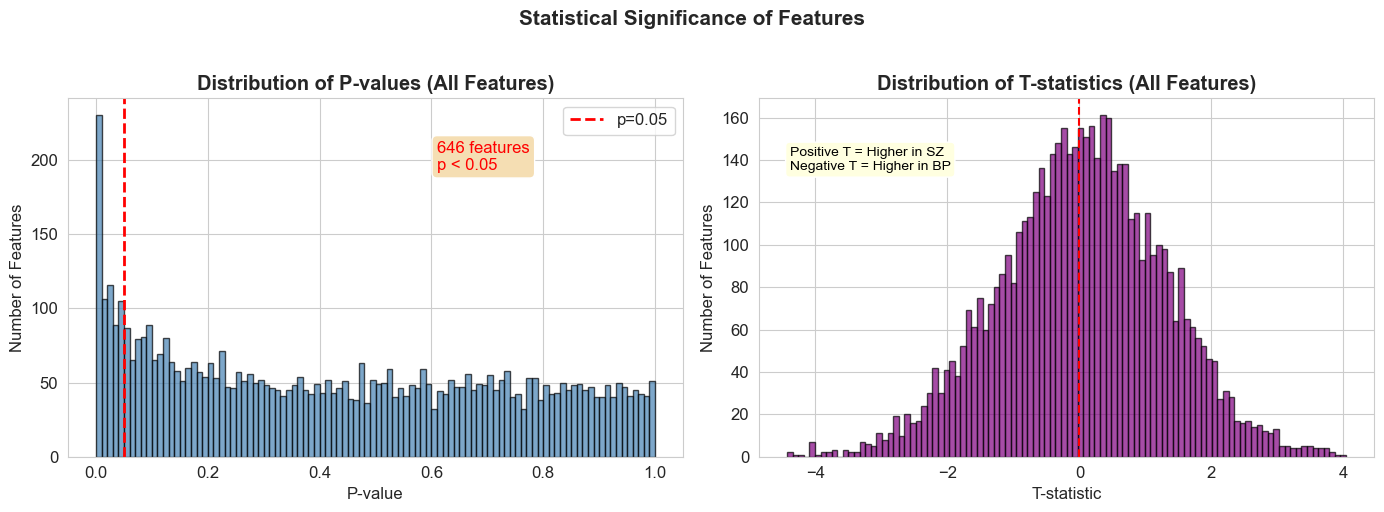

In [7]:
# EDA T test for all features 
from scipy.stats import ttest_ind

print("Running t-test for all 5,460 features...")

t_statistics = np.zeros(5460)
p_values = np.zeros(5460)

for i in range(5460):
    t_stat, p_val = ttest_ind(
        X_train[y_train==0, i],   # BP values for feature i
        X_train[y_train==1, i]    # SZ values for feature i
    )
    t_statistics[i] = t_stat
    p_values[i] = p_val

# Summary
n_sig_05  = np.sum(p_values < 0.05)
n_sig_01  = np.sum(p_values < 0.01)
n_sig_001 = np.sum(p_values < 0.001)

print(f"\n{'='*50}")
print(f"T-TEST RESULTS (5,460 features)")
print(f"{'='*50}")
print(f"Significant (p < 0.05)  : {n_sig_05}  ({100*n_sig_05/5460:.1f}%)")
print(f"Significant (p < 0.01)  : {n_sig_01}  ({100*n_sig_01/5460:.1f}%)")
print(f"Significant (p < 0.001) : {n_sig_001} ({100*n_sig_001/5460:.1f}%)")
print(f"\nTop 10 most significant features:")
top10 = np.argsort(p_values)[:10]
for rank, idx in enumerate(top10):
    print(f"  Rank {rank+1}: Feature {idx:4d} | "
          f"t={t_statistics[idx]:6.2f} | p={p_values[idx]:.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P-value distribution
axes[0].hist(p_values, bins=100,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.05, color='red', linestyle='--',
                linewidth=2, label='p=0.05')
axes[0].set_title('Distribution of P-values (All Features)', fontweight='bold')
axes[0].set_xlabel('P-value')
axes[0].set_ylabel('Number of Features')
axes[0].legend()
axes[0].text(0.6, 0.8,
             f'{n_sig_05} features\np < 0.05',
             transform=axes[0].transAxes,
             fontsize=12, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat'))

# T-statistic distribution
axes[1].hist(t_statistics, bins=100,
             color='purple', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of T-statistics (All Features)', fontweight='bold')
axes[1].set_xlabel('T-statistic')
axes[1].set_ylabel('Number of Features')
axes[1].text(0.05, 0.8,
             f'Positive T = Higher in SZ\nNegative T = Higher in BP',
             transform=axes[1].transAxes,
             fontsize=10, color='black',
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.suptitle('Statistical Significance of Features',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_4_ttest_results.png', dpi=150, bbox_inches='tight')
plt.show()

OUTLIER DETECTION
Outliers by mean (|z|>3): 7
Outliers by std  (|z|>3): 3
Total unique outliers   : 10
  Patient sub174 (BP): mean=0.0607, std=0.2747
  Patient sub441 (BP): mean=0.0829, std=0.2777
  Patient sub628 (BP): mean=0.0446, std=0.4007
  Patient sub141 (SZ): mean=0.0682, std=0.3269
  Patient sub263 (SZ): mean=0.0147, std=0.3509
  Patient sub318 (SZ): mean=0.0585, std=0.3127
  Patient sub449 (SZ): mean=0.0585, std=0.2425
  Patient sub452 (SZ): mean=0.0368, std=0.3396
  Patient sub568 (SZ): mean=0.0665, std=0.3129
  Patient sub745 (SZ): mean=0.0634, std=0.2478


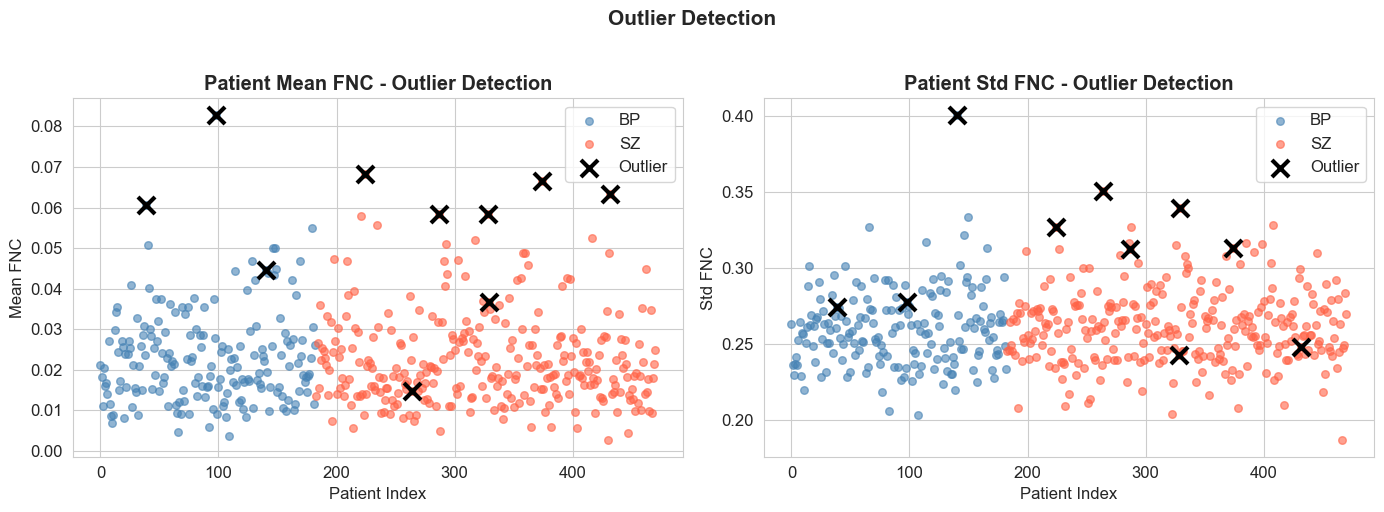

In [8]:
# EDA outlier detection
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

# Z-score based outlier detection
patient_means = X_train.mean(axis=1)
patient_stds  = X_train.std(axis=1)

z_mean = np.abs(stats.zscore(patient_means))
z_std  = np.abs(stats.zscore(patient_stds))

outliers_mean = np.where(z_mean > 3)[0]
outliers_std  = np.where(z_std > 3)[0]
all_outliers  = np.unique(np.concatenate([outliers_mean, outliers_std]))

print(f"Outliers by mean (|z|>3): {len(outliers_mean)}")
print(f"Outliers by std  (|z|>3): {len(outliers_std)}")
print(f"Total unique outliers   : {len(all_outliers)}")

if len(all_outliers) > 0:
    for idx in all_outliers:
        label = 'BP' if y_train[idx] == 0 else 'SZ'
        print(f"  Patient {patient_ids[idx]} ({label}): "
              f"mean={patient_means[idx]:.4f}, std={patient_stds[idx]:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title, ylabel in zip(
    axes,
    [patient_means, patient_stds],
    ['Patient Mean FNC - Outlier Detection',
     'Patient Std FNC - Outlier Detection'],
    ['Mean FNC', 'Std FNC']
):
    bp_idx = np.where(y_train == 0)[0]
    sz_idx = np.where(y_train == 1)[0]
    
    ax.scatter(bp_idx, values[bp_idx],
               color='steelblue', alpha=0.6, s=30, label='BP')
    ax.scatter(sz_idx, values[sz_idx],
               color='tomato', alpha=0.6, s=30, label='SZ')
    
    if len(all_outliers) > 0:
        ax.scatter(all_outliers, values[all_outliers],
                   color='black', s=150, marker='x',
                   linewidths=3, label='Outlier', zorder=5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Patient Index')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('Outlier Detection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_5_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

Running PCA...
Variance explained by components:
  PC1: 5.26%
  PC2: 3.67%
  PC3: 3.13%
  PC4: 2.59%
  PC5: 2.27%
  Total (10 PCs): 26.58%


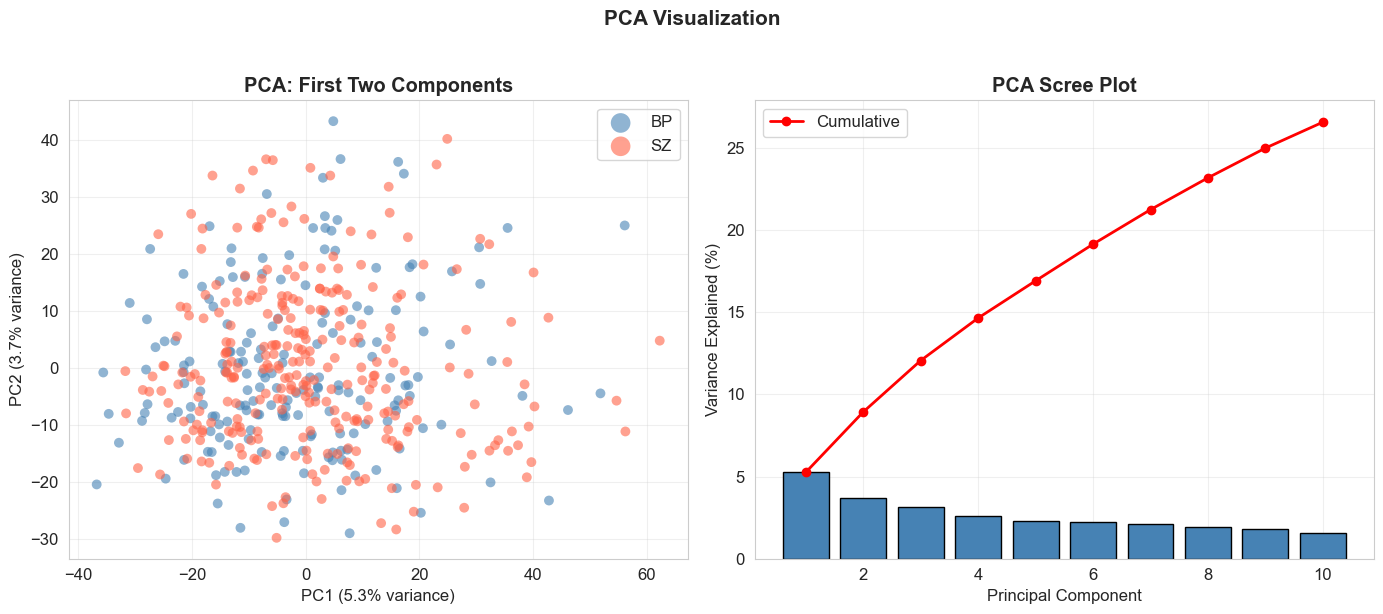

In [9]:
# EDA PCA visualization 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Running PCA...")

# Standardize first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by components:")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var:.2%}")
print(f"  Total (10 PCs): {pca.explained_variance_ratio_.sum():.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA scatter
for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['BP', 'SZ']):
    mask = y_train == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=name, alpha=0.6, s=50, edgecolors='none')

axes[0].set_title('PCA: First Two Components', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(markerscale=2)
axes[0].grid(True, alpha=0.3)

# Scree plot
axes[1].bar(range(1, 11), pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='black')
axes[1].plot(range(1, 11),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             'r-o', linewidth=2, label='Cumulative')
axes[1].set_title('PCA Scree Plot', fontweight='bold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Visualization', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_6_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# EDA summary
print("""
╔══════════════════════════════════════════════════╗
║           EDA COMPLETE - KEY FINDINGS            ║
╠══════════════════════════════════════════════════╣
""")

print(f"1. DATASET:")
print(f"   Total patients : {X_train.shape[0]}")
print(f"   BP patients    : {n_bp} ({100*n_bp/total:.1f}%)")
print(f"   SZ patients    : {n_sz} ({100*n_sz/total:.1f}%)")
print(f"   Features       : {X_train.shape[1]}")

print(f"\n2. DATA QUALITY:")
print(f"   NaN/Inf values : None ✓")
print(f"   Value range    : [{X_train.min():.3f}, {X_train.max():.3f}] ✓")
print(f"   Outliers       : {len(all_outliers)} patients")

print(f"\n3. DISCRIMINATIVE FEATURES:")
print(f"   Significant (p<0.05)  : {n_sig_05}/{5460} ({100*n_sig_05/5460:.1f}%)")
print(f"   Significant (p<0.001) : {n_sig_001}/{5460} ({100*n_sig_001/5460:.1f}%)")

print(f"\n4. CLASS IMBALANCE:")
print(f"   Ratio (SZ:BP)  : {ratio:.2f}:1")
print(f"   Action needed  : Use balanced class weights ✓")

print(f"\n5. NEXT STEPS:")
print(f"   → Week 1: SVM baseline with 5,460 features")
print(f"   → Use balanced class weights")
print(f"   → Use stratified 5-fold CV")
print(f"   → Feature selection within each CV fold")

print(f"""
╠══════════════════════════════════════════════════╣
║  Files saved:                                    ║
║  eda_1_class_distribution.png                    ║
║  eda_2_fnc_distributions.png                     ║
║  eda_3_feature_analysis.png                      ║
║  eda_4_ttest_results.png                         ║
║  eda_5_outliers.png                              ║
║  eda_6_pca.png                                   ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║           EDA COMPLETE - KEY FINDINGS            ║
╠══════════════════════════════════════════════════╣

1. DATASET:
   Total patients : 471
   BP patients    : 183 (38.9%)
   SZ patients    : 288 (61.1%)
   Features       : 5460

2. DATA QUALITY:
   NaN/Inf values : None ✓
   Value range    : [-0.989, 0.999] ✓
   Outliers       : 10 patients

3. DISCRIMINATIVE FEATURES:
   Significant (p<0.05)  : 646/5460 (11.8%)
   Significant (p<0.001) : 56/5460 (1.0%)

4. CLASS IMBALANCE:
   Ratio (SZ:BP)  : 1.57:1
   Action needed  : Use balanced class weights ✓

5. NEXT STEPS:
   → Week 1: SVM baseline with 5,460 features
   → Use balanced class weights
   → Use stratified 5-fold CV
   → Feature selection within each CV fold

╠══════════════════════════════════════════════════╣
║  Files saved:                                    ║
║  eda_1_class_distribution.png                    ║
║  eda_2_fnc_distributions.png                     ║
║  eda_